## Installing dependencies

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import optuna
from catboost import CatBoostClassifier, Pool
from xgboost import XGBClassifier
from pytabkit import RealMLP_TD_Classifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from pathlib import Path
from tempfile import TemporaryDirectory

from autogluon.tabular import TabularPredictor
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

import torch

torch.set_float32_matmul_precision("high")

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
              
RANDOM_SEED = 42

In [21]:
train_df = pd.read_csv('datasets/train.csv', index_col="id")
train_df['Heart Disease'] = train_df['Heart Disease'].replace({'Presence': 1, 'Absence': 0})
test_df = pd.read_csv('datasets/test.csv', index_col="id")

feature_columns = [c for c in train_df.columns if c not in ['Heart Disease', 'id']]
continuous_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical_features = [column for column in feature_columns if column not in continuous_features]

print(f'Train: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns')
print(f'Test:  {test_df.shape[0]:,} rows x {test_df.shape[1]} columns')
train_df.head()


Train: 630,000 rows x 14 columns
Test:  270,000 rows x 13 columns


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


## Data audit

In [8]:
train_df.info()
print(train_df[continuous_features].describe())

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  object 
dtypes: float64(1), 

In [36]:
for df in (train_df, test_df):
    df[continuous_features] = df[continuous_features].replace([np.inf, -np.inf], np.nan)

train_df = train_df.drop_duplicates(subset=feature_columns)

print(f"Missing values (train): {train_df.isna().sum().sum():,}")
print(f"Missing values (test):  {test_df.isna().sum().sum():,}")

Missing values (train): 0
Missing values (test):  0


In [18]:
Target_counts = train_df['Heart Disease'].value_counts().sort_index()
Target_shares = Target_counts / len(train_df) * 100

for label in Target_counts.index:
    print(f'{label}: {Target_counts[label]:,} rows ({Target_shares[label]:.2f}%)')

Absence: 347,546 rows (55.17%)
Presence: 282,454 rows (44.83%)


## EDA

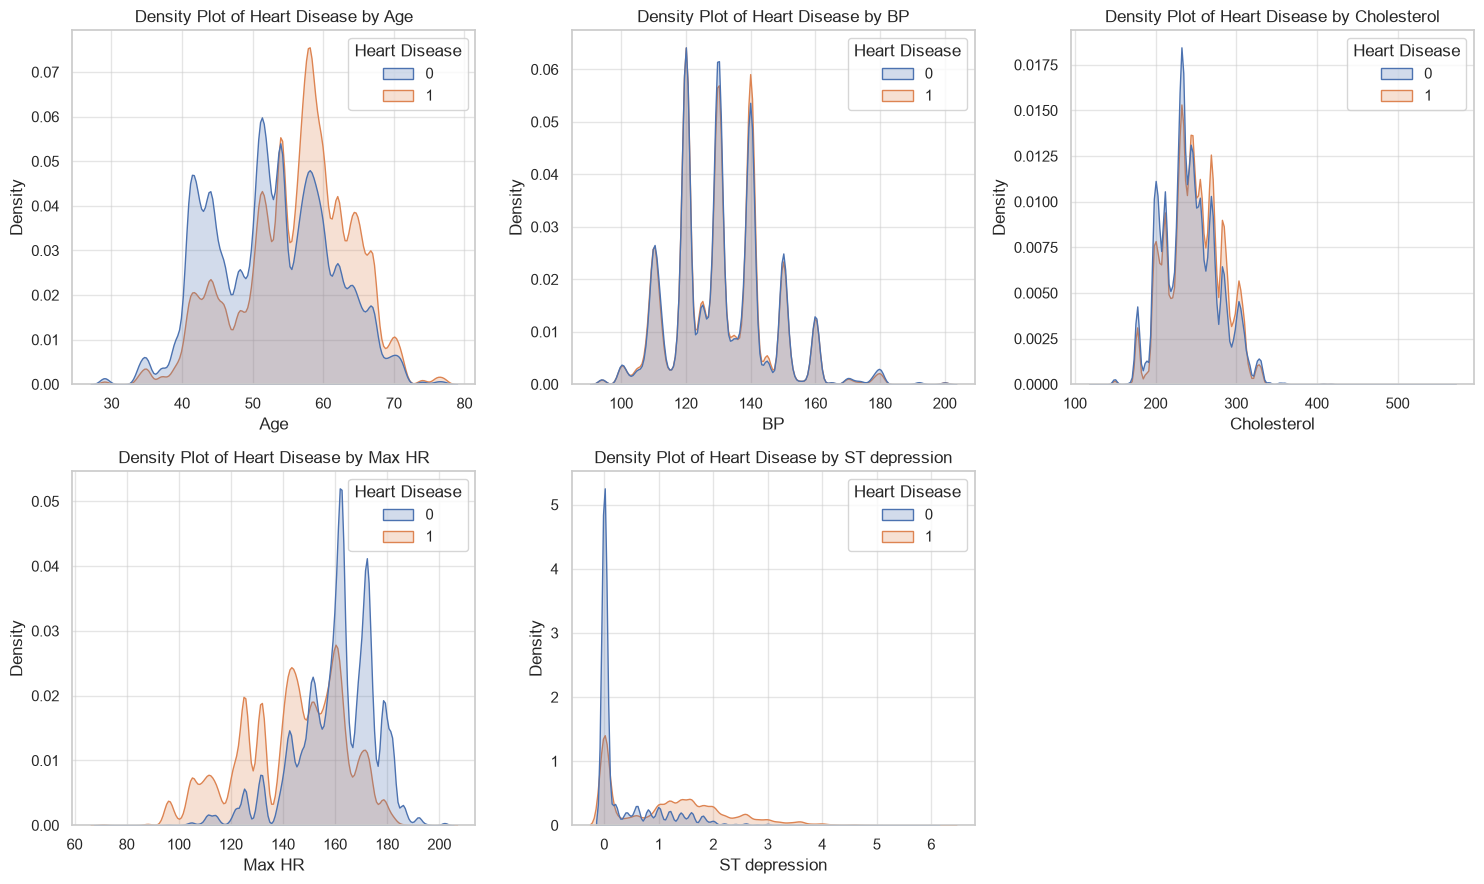

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, continuous_features):
    sns.kdeplot(
        data=train_df,
        x=col,
        hue='Heart Disease',
        fill=True,
        common_norm=False,
        ax=ax
    )

    ax.set_title(f'Density Plot of Heart Disease by {col}')

for ax in axes[len(continuous_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

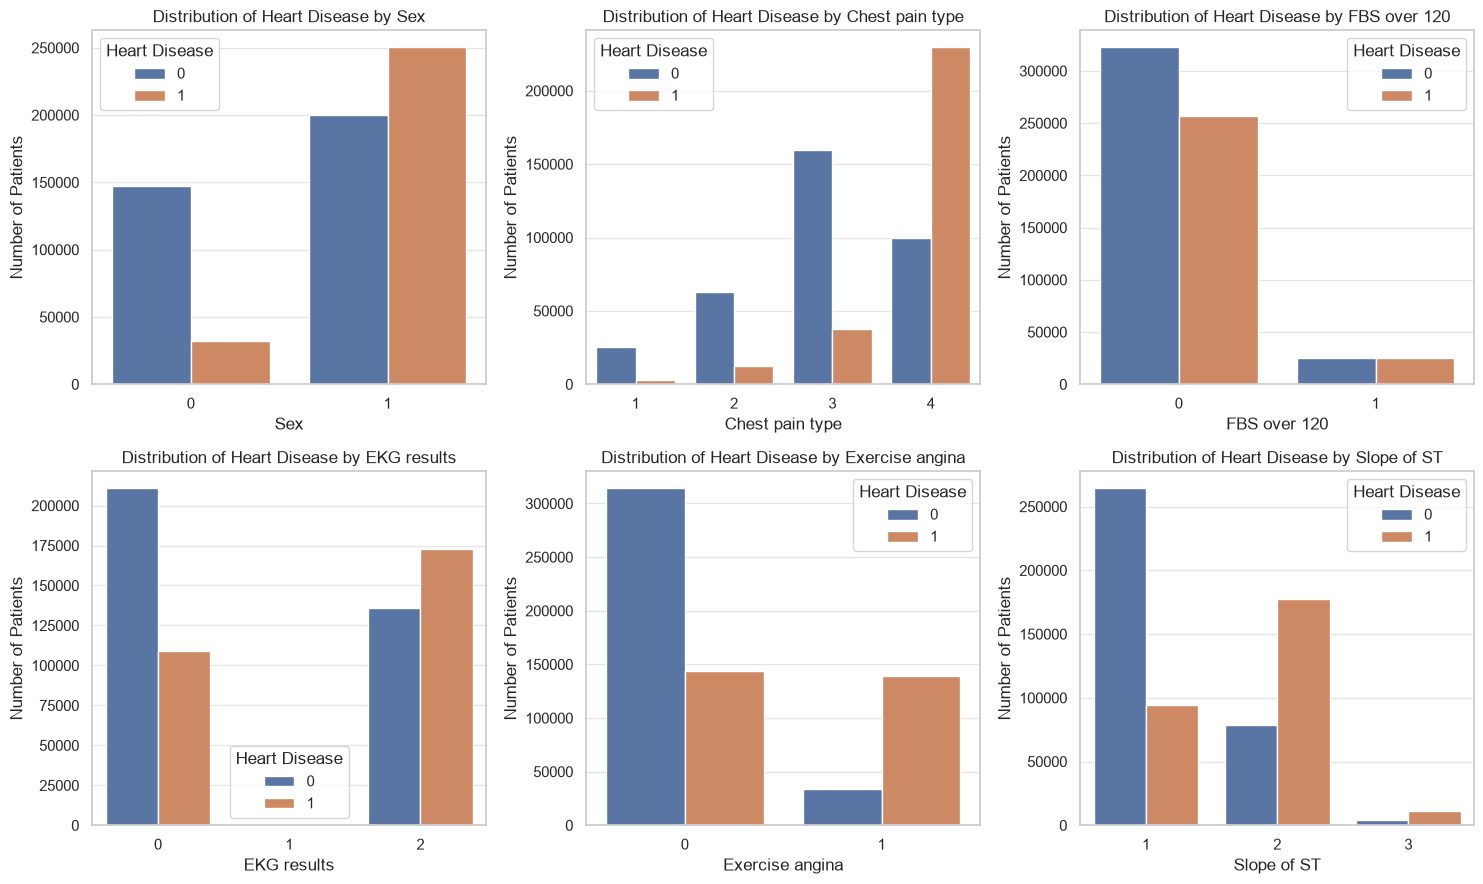

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, categorical_features):
    sns.countplot(
        data=train_df,
        x=col,
        hue='Heart Disease',
        ax=ax
    )

    ax.set_ylabel('Number of Patients')
    ax.set_title(f'Distribution of Heart Disease by {col}')

for ax in axes[len(categorical_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

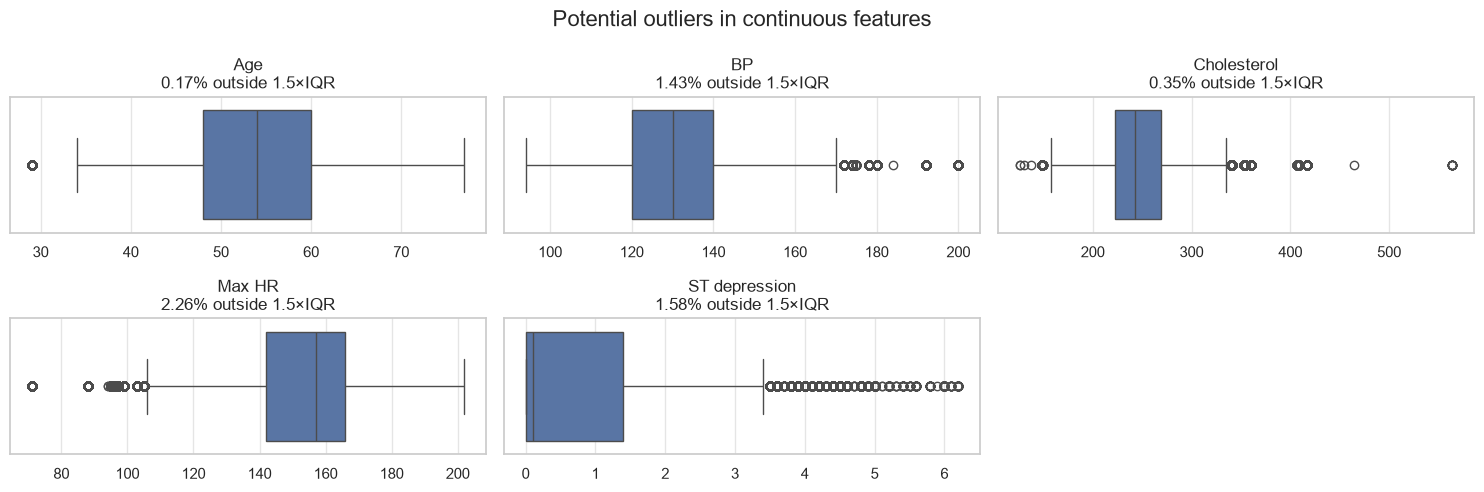

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 5))
axes = axes.ravel()

for ax, col in zip(axes, continuous_features):
    values = train_df[col].dropna()

    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_share = ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).mean() * 100

    sns.boxplot(x=values, ax=ax)
    ax.set_title(f'{col}\n{outlier_share:.2f}% outside 1.5×IQR')
    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[len(continuous_features):]:
    ax.remove()

fig.suptitle('Potential outliers in continuous features', fontsize=16)
plt.tight_layout()
plt.show()

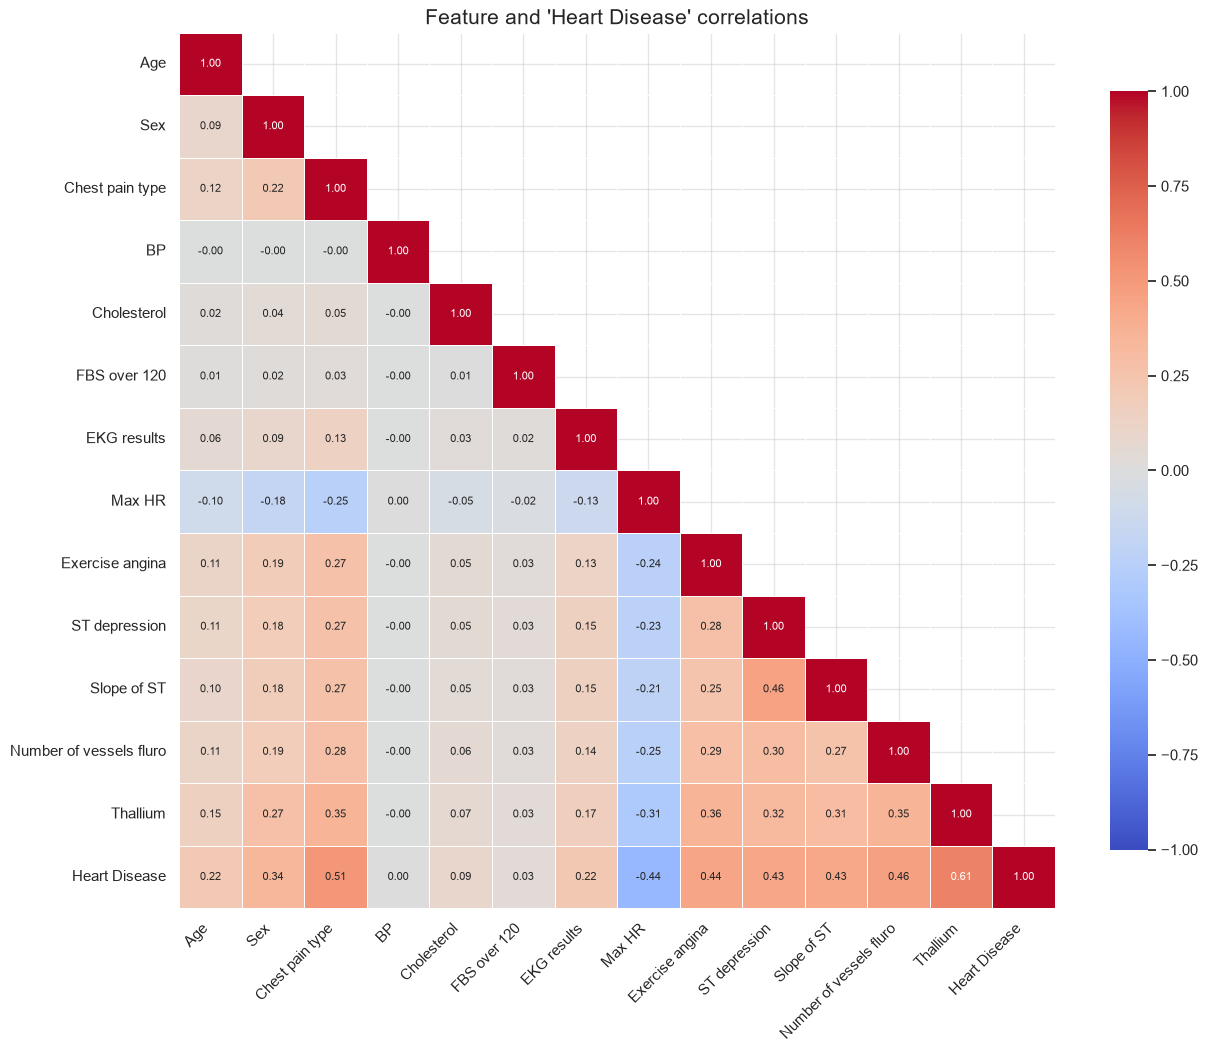

In [23]:
corr = train_df.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(13, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.title("Feature and 'Heart Disease' correlations", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature creation

This section creates a compact set of engineered features. The goal is not to copy the winning solution, but to add a few interpretable candidate features that can be tested against the baseline in the next step.


In [22]:
# Bin features
def add_bin_features(df):
    df = df.copy()

    bin_features = {
        'Age': 'Age_bin',
        'BP': 'BP_bin',
        'Cholesterol': 'Cholesterol_bin',
        'Max HR': 'MaxHR_bin',
        'ST depression': 'ST_bin',
    }

    for col, new_col in bin_features.items():
        df[new_col] = pd.cut(df[col], bins=5, labels=False, duplicates='drop').astype('category')

    return df


# Digit features
def add_digit_features(df):
    df = df.copy()

    cols = {
        'Age': 'Age',
        'BP': 'BP',
        'Cholesterol': 'Chol',
        'Max HR': 'MaxHR'
    }

    for col, prefix in cols.items():
        x = df[col].astype(int)
        df[f'{prefix}_units'] = x % 10
        df[f'{prefix}_tens'] = (x // 10) % 10
        df[f'{prefix}_hundreds'] = (x // 100) % 10

    df['ST_depression_1'] = (df['ST depression'] * 10 % 10).astype(int)

    return df


In [28]:
X = train_df.drop(columns=['Heart Disease']).copy()
X_bin = add_bin_features(X)
X_digit = add_digit_features(X)
X_digit_bin = add_digit_features(X_bin)

y = train_df['Heart Disease'].astype(int).copy()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED,
)

for name, df in {
    "X": X,
    "X_bin": X_bin,
    "X_digit": X_digit,
    "X_digit_bin": X_digit_bin,
}.items():
    print(f'{name}: ', df.columns.tolist())

X:  ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
X_bin:  ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Age_bin', 'BP_bin', 'Cholesterol_bin', 'MaxHR_bin', 'ST_bin']
X_digit:  ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Age_units', 'Age_tens', 'Age_hundreds', 'BP_units', 'BP_tens', 'BP_hundreds', 'Chol_units', 'Chol_tens', 'Chol_hundreds', 'MaxHR_units', 'MaxHR_tens', 'MaxHR_hundreds', 'ST_depression_1']
X_digit_bin:  ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number

## Baseline models

The goal of this section is to create a clean reference point before feature engineering. The models use only the original competition features, without bins, digit features, or interactions.

In [7]:
def run_sklearn_oof_baseline(model_name, estimator, X, y, cv):
    oof_predictions = np.zeros(len(y), dtype=float)
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = clone(estimator)

        model.fit(X_train, y_train)

        final_estimator = (
            model.named_steps.get("model")
            if isinstance(model, Pipeline)
            else model
        )

        if isinstance(final_estimator, XGBClassifier):
            final_estimator.set_params(device="cpu")

        valid_predictions = model.predict_proba(X_valid)[:, 1]

        oof_predictions[valid_idx] = valid_predictions

        fold_auc = roc_auc_score(y_valid, valid_predictions)
        fold_scores.append(fold_auc)

        print(f"{model_name} fold {fold}: AUC = {fold_auc:.6f}")

    oof_auc = roc_auc_score(y, oof_predictions)

    print(f"{model_name} OOF AUC: {oof_auc:.6f}")

    return oof_predictions, fold_scores, oof_auc

def create_logistic_regression_pipeline(continuous_features, categorical_features, params):
    logistic_preprocessor = ColumnTransformer(
        transformers=[
            ('continuous', StandardScaler(), continuous_features),
            ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ]
    )

    logistic_pipeline = Pipeline(
        steps=[
            ('preprocessor', logistic_preprocessor),
            ('model', LogisticRegression(**params)),
        ]
    )

    return logistic_pipeline

def create_xgboost_pipeline(continuous_features, categorical_features, params):
    xgboost_preprocessor = ColumnTransformer(
        transformers=[
            ('continuous', 'passthrough', continuous_features),
            ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ]
    )

    xgboost_pipeline = Pipeline(
        steps=[
            ('preprocessor', xgboost_preprocessor),
            ('model', XGBClassifier(**params)),
        ]
    )

    return xgboost_pipeline

def run_catboost_oof_baseline(model_name, X, y, cv, categorical_features, params):
    oof_predictions = np.zeros(len(y), dtype=float)
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        train_pool = Pool(X_train, y_train, categorical_features=categorical_features)
        valid_pool = Pool(X_valid, y_valid, categorical_features=categorical_features)

        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=valid_pool,
            early_stopping_rounds=100,
            use_best_model=True,
        )

        valid_predictions = model.predict_proba(valid_pool)[:, 1]
        oof_predictions[valid_idx] = valid_predictions

        fold_auc = roc_auc_score(y_valid, valid_predictions)
        fold_scores.append(fold_auc)
        print(
            f'{model_name} fold {fold}: AUC = {fold_auc:.6f}'
        )

    oof_auc = roc_auc_score(y, oof_predictions)

    print(f'{model_name} OOF AUC: {oof_auc:.6f}')

    return oof_predictions, fold_scores, oof_auc

def run_realmlp_oof_baseline(model_name, X, y, cv, categorical_features, params):
    oof_predictions = np.zeros(len(y), dtype=float)
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = RealMLP_TD_Classifier(**params)
        model.fit(
            X_train,
            y_train,
            X_valid,
            y_valid,
            cat_col_names=categorical_features,
        )

        valid_predictions = model.predict_proba(X_valid)[:, 1]
        oof_predictions[valid_idx] = valid_predictions

        fold_auc = roc_auc_score(y_valid, valid_predictions)
        fold_scores.append(fold_auc)

        print(f'{model_name} fold {fold}: AUC = {fold_auc:.6f}')

    oof_auc = roc_auc_score(y, oof_predictions)

    print(f'{model_name} OOF AUC: {oof_auc:.6f}')

    return oof_predictions, fold_scores, oof_auc

def prepare_lightgbm_categories(
    X_train,
    X_valid,
    categorical_features,
):
    """
    Переводит категориальные признаки в pandas category.

    Категории определяются только по train-fold. Значения, которые встречаются
    только в validation-fold, становятся NaN и обрабатываются LightGBM
    как неизвестные/пропущенные.
    """
    X_train = X_train.copy()
    X_valid = X_valid.copy()

    for column in categorical_features:
        train_categories = pd.Index(
            X_train[column].dropna().unique()
        )

        X_train[column] = pd.Categorical(
            X_train[column],
            categories=train_categories,
        )

        X_valid[column] = pd.Categorical(
            X_valid[column],
            categories=train_categories,
        )

    return X_train, X_valid


def run_lightgbm_oof_baseline(
    model_name,
    X,
    y,
    cv,
    categorical_features,
    params,
):
    oof_predictions = np.zeros(len(y), dtype=float)
    fold_scores = []

    categorical_features = list(categorical_features)

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X, y),
        start=1,
    ):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        X_train, X_valid = prepare_lightgbm_categories(
            X_train=X_train,
            X_valid=X_valid,
            categorical_features=categorical_features,
        )

        model = LGBMClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="auc",
            categorical_feature=categorical_features,
            callbacks=[
                early_stopping(
                    stopping_rounds=100,
                    first_metric_only=True,
                    verbose=False,
                ),
                log_evaluation(period=0),
            ],
        )

        valid_predictions = model.predict_proba(
            X_valid,
            num_iteration=model.best_iteration_,
        )[:, 1]

        oof_predictions[valid_idx] = valid_predictions

        fold_auc = roc_auc_score(
            y_valid,
            valid_predictions,
        )
        fold_scores.append(fold_auc)

        print(
            f"{model_name} fold {fold}: "
            f"AUC = {fold_auc:.6f}"
        )

    oof_auc = roc_auc_score(y, oof_predictions)

    print(f"{model_name} OOF AUC: {oof_auc:.6f}")

    return oof_predictions, fold_scores, oof_auc

def run_autogluon_oof_baseline(
    model_name,
    X,
    y,
    cv,
    fit_params,
):
    oof_predictions = np.zeros(len(y), dtype=float)
    fold_scores = []

    label_column = "__autogluon_target__"

    while label_column in X.columns:
        label_column = f"_{label_column}"

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X, y),
        start=1,
    ):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()

        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        train_data = X_train.copy()
        train_data[label_column] = y_train.to_numpy()

        # Для каждого fold нужен отдельный каталог:
        # AutoGluon сохраняет обученные модели на диск.
        with TemporaryDirectory(
            prefix=f"autogluon_fold_{fold}_"
        ) as temporary_directory:
            predictor_path = (
                Path(temporary_directory) / "predictor"
            )

            predictor = TabularPredictor(
                label=label_column,
                problem_type="binary",
                eval_metric="roc_auc",
                path=str(predictor_path),
                verbosity=0,
            )

            predictor.fit(
                train_data=train_data,
                **fit_params,
            )

            # Получаем обе колонки вероятностей и явно выбираем
            # положительный класс AutoGluon.
            valid_probabilities = predictor.predict_proba(
                X_valid,
                as_pandas=True,
                as_multiclass=True,
            )

            positive_class = predictor.positive_class

            valid_predictions = valid_probabilities[
                positive_class
            ].to_numpy(dtype=float)

            del predictor

        oof_predictions[valid_idx] = valid_predictions

        fold_auc = roc_auc_score(
            y_valid,
            valid_predictions,
        )
        fold_scores.append(fold_auc)

        print(
            f"{model_name} fold {fold}: "
            f"AUC = {fold_auc:.6f}"
        )

    oof_auc = roc_auc_score(y, oof_predictions)

    print(f"{model_name} OOF AUC: {oof_auc:.6f}")

    return oof_predictions, fold_scores, oof_auc

## Model comparison

This section checks whether the engineered features improve validation quality. We reuse the baseline functions and pass the engineered dataset into them.

In [9]:
categorical_features_bin = categorical_features + ['Age_bin', 'BP_bin', 'Cholesterol_bin', 'MaxHR_bin', 'ST_bin']
continuous_features_digit = [column for column in X_digit if column not in categorical_features_bin]

In [14]:
configs = [
    ("Base", X, continuous_features, categorical_features),
    ("Bin", X_bin, continuous_features, categorical_features_bin),
    ("Digit", X_digit, continuous_features_digit, categorical_features),
    ("Bin + Digit", X_digit_bin, continuous_features_digit, categorical_features_bin),
]

result = []

for name, X_data, con, cat in configs:
    logistic_regression_oof, logistic_regression_fold_scores, logistic_regression_oof_auc = run_sklearn_oof_baseline(
        model_name=f"Logistic Regression ({name})",
        estimator=create_logistic_regression_pipeline(
            continuous_features=con,
            categorical_features=cat,
            params={
                "C": 0.1,
                "max_iter": 1000,
                "solver": "lbfgs",
                "random_state": RANDOM_SEED,
            }
        ),
        X=X_data,
        y=y,
        cv=cv,
    )

    xgboost_oof, xgboost_fold_scores, xgboost_oof_auc = run_sklearn_oof_baseline(
        model_name=f"XGBoost ({name})",
        estimator=create_xgboost_pipeline(
            continuous_features=con,
            categorical_features=cat,
            params={
                "n_estimators": 1000,
                "learning_rate": 0.05,
                "max_depth": 4,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "objective": "binary:logistic",
                "eval_metric": "auc",
                "random_state": RANDOM_SEED,
                "n_jobs": -1,
                "tree_method": "hist",
                "device": "cuda",
            }
        ),
        X=X_data,
        y=y,
        cv=cv,
    )

    catboost_oof, catboost_fold_scores, catboost_oof_auc = run_catboost_oof_baseline(
        model_name=f"CatBoost ({name})",
        X=X_data,
        y=y,
        cv=cv,
        categorical_features=cat,
        params={
            "iterations": 1000,
            "learning_rate": 0.05,
            "depth": 6,
            "l2_leaf_reg": 3.0,
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "metric_period": 10,
            "random_seed": RANDOM_SEED,
            "task_type": "GPU",
            "devices": "0",
            "allow_writing_files": False,
            "verbose": False,
        }
    )

    realmlp_oof, realmlp_fold_scores, realmlp_oof_auc = run_realmlp_oof_baseline(
        model_name=f"RealMLP ({name})",
        X=X_data,
        y=y,
        cv=cv,
        categorical_features=cat,
        params={
            "device": "cuda",
            "RANDOM_SEED": RANDOM_SEED,
            "n_cv": 1,
            "n_refit": 0,
            "n_epochs": 128,
            "batch_size": 512,
            "val_metric_name": "cross_entropy",
            "use_ls": False,
            "verbosity": 0,
        },
    )

    lightgbm_oof, lightgbm_fold_scores, lightgbm_oof_auc = (
        run_lightgbm_oof_baseline(
            model_name=f"LightGBM ({name})",
            X=X_data,
            y=y,
            cv=cv,
            categorical_features=cat,
            params={
                "n_estimators": 5000,
                "learning_rate": 0.03,
                "num_leaves": 31,
                "max_depth": -1,
                "min_child_samples": 20,
                "subsample": 0.8,
                "subsample_freq": 1,
                "colsample_bytree": 0.8,
                "reg_alpha": 0.0,
                "reg_lambda": 1.0,
                "objective": "binary",
                "random_state": RANDOM_SEED,
                "n_jobs": -1,
                "device_type": "gpu",
                "max_bin": 63,
                "verbosity": -1,
            },
        )
    )

    autogluon_oof, autogluon_fold_scores, autogluon_oof_auc = (
        run_autogluon_oof_baseline(
            model_name=f"AutoGluon ({name})",
            X=X_data,
            y=y,
            cv=cv,
            fit_params={
                "time_limit": 300,
                "presets": "medium_quality",
                "num_cpus": "auto",
                "num_gpus": 1,
            },
        )
    )

    result.extend(
        [
            {
                "Model": "Logistic Regression",
                "Features": name,
                "OOF AUC": logistic_regression_oof_auc,
            },
            {
                "Model": "XGBoost",
                "Features": name,
                "OOF AUC": xgboost_oof_auc,
            },
            {
                "Model": "LightGBM",
                "Features": name,
                "OOF AUC": lightgbm_oof_auc,
            },
            {
                "Model": "CatBoost",
                "Features": name,
                "OOF AUC": catboost_oof_auc,
            },
            {
                "Model": "RealMLP",
                "Features": name,
                "OOF AUC": realmlp_oof_auc,
            },
            {
                "Model": "AutoGluon",
                "Features": name,
                "OOF AUC": autogluon_oof_auc,
            },
        ]
    )

model_comparison = (
    pd.DataFrame(result)
    .sort_values("OOF AUC", ascending=False)
    .reset_index(drop=True)
)

model_comparison.to_csv(
    "model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

print(model_comparison)

Logistic Regression (Base) fold 1: AUC = 0.953237
Logistic Regression (Base) fold 2: AUC = 0.952257
Logistic Regression (Base) fold 3: AUC = 0.952975
Logistic Regression (Base) fold 4: AUC = 0.952590
Logistic Regression (Base) fold 5: AUC = 0.953321
Logistic Regression (Base) OOF AUC: 0.952874
Logistic Regression (Bin) fold 1: AUC = 0.953485
Logistic Regression (Bin) fold 2: AUC = 0.952507
Logistic Regression (Bin) fold 3: AUC = 0.953252
Logistic Regression (Bin) fold 4: AUC = 0.952872
Logistic Regression (Bin) fold 5: AUC = 0.953555
Logistic Regression (Bin) OOF AUC: 0.953132
Logistic Regression (Digit) fold 1: AUC = 0.953435
Logistic Regression (Digit) fold 2: AUC = 0.952416
Logistic Regression (Digit) fold 3: AUC = 0.953162
Logistic Regression (Digit) fold 4: AUC = 0.952771
Logistic Regression (Digit) fold 5: AUC = 0.953482
Logistic Regression (Digit) OOF AUC: 0.953052
Logistic Regression (Bin + Digit) fold 1: AUC = 0.953648
Logistic Regression (Bin + Digit) fold 2: AUC = 0.952657
L

In [9]:
X = pd.read_csv('datasets/train.csv')
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST',
                'Number of vessels fluro', 'Thallium', 'Age_bin', 'BP_bin', 'Cholesterol_bin', 'MaxHR_bin',
                'ST_bin']

# Split continuous features into bins
X['Age_bin'] = pd.cut(X['Age'], bins=5).astype(str)
X['BP_bin'] = pd.cut(X['BP'], bins=5).astype(str)
X['Cholesterol_bin'] = pd.cut(X['Cholesterol'], bins=5).astype(str)
X['MaxHR_bin'] = pd.cut(X['Max HR'], bins=5).astype(str)
X['ST_bin'] = pd.cut(X['ST depression'], bins=5).astype(str)

#Digit
X['Age_units'] = X['Age'] % 10
X['Age_tens'] = (X['Age'] // 10) % 10

X['BP_units'] = X['BP'] % 10
X['BP_tens'] = (X['BP'] // 10) % 10
X['BP_hundreds'] = (X['BP'] // 100) % 10

X['Chol_units'] = X['Cholesterol'] % 10
X['Chol_tens'] = (X['Cholesterol'] // 10) % 10
X['Chol_hundreds'] = (X['Cholesterol'] // 100) % 10

X['MaxHR_units'] = X['Max HR'] % 10
X['MaxHR_tens'] = (X['Max HR'] // 10) % 10
X['MaxHR_hundreds'] = (X['Max HR'] // 100) % 10

X['St_depression_1'] = (X['ST depression'] * 10 % 10).astype(int)

X.replace({'Heart Disease': {'Presence': 1, 'Absence': 0}}, inplace=True)
y = X['Heart Disease'].astype(int)
X.drop(['Heart Disease', 'id'], axis=1, inplace=True)


def objective(trial: optuna.Trial) -> float:
    params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),

        'iterations': 1000,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'task_type': 'GPU',
        'devices': '0',
        'verbose': False
    }

    kf = StratifiedKFold(n_splits=5, shuffle=True, RANDOM_SEED=42)
    scores = []

    for train_index, test_index in kf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        train_pool = Pool(X_train, y_train, categorical_features=categorical_features)
        test_pool = Pool(X_test, y_test, categorical_features=categorical_features)

        model = CatBoostClassifier(**params)

        model.fit(train_pool,
                  eval_set=test_pool,
                  early_stopping_rounds=100)

        preds = model.predict_proba(test_pool)[:, 1]
        score = roc_auc_score(y_test, preds)
        scores.append(score)

    return np.mean(scores)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500)

print('Number of finished trials: {}'.format(len(study.trials)))

print('Best trial:')
trial = study.best_trial

print('Value: {}'.format(trial.value))

print('Params: ')
for key, value in trial.params.items():
    print('{}: {}'.format(key, value))

# Best result: 0.955525302701582 with parameters {'iterations': 1209, 'depth': 5, 'learning_rate': 0.08375766130052575, 'l2_leaf_reg': 3.9695263497534183}

KeyboardInterrupt: 

In [21]:
X = pd.read_csv('test.csv')

#Bin
X['Age_bin'] = pd.cut(X['Age'], bins=5).astype(str)
X['BP_bin'] = pd.cut(X['BP'], bins=5).astype(str)
X['Cholesterol_bin'] = pd.cut(X['Cholesterol'], bins=5).astype(str)
X['MaxHR_bin'] = pd.cut(X['Max HR'], bins=5).astype(str)
X['ST_bin'] = pd.cut(X['ST depression'], bins=5).astype(str)

#Digit
X['Age_units'] = X['Age'] % 10
X['Age_tens'] = (X['Age'] // 10) % 10

X['BP_units'] = X['BP'] % 10
X['BP_tens'] = (X['BP'] // 10) % 10
X['BP_hundreds'] = (X['BP'] // 100) % 10

X['Chol_units'] = X['Cholesterol'] % 10
X['Chol_tens'] = (X['Cholesterol'] // 10) % 10
X['Chol_hundreds'] = (X['Cholesterol'] // 100) % 10

X['MaxHR_units'] = X['Max HR'] % 10
X['MaxHR_tens'] = (X['Max HR'] // 10) % 10
X['MaxHR_hundreds'] = (X['Max HR'] // 100) % 10

id = X['id']
X.drop('id', axis=1, inplace=True)
preds = model.predict_proba(X)[:, 1]

sample_submission = pd.DataFrame(data={'id': id, 'Heart Disease': preds})
sample_submission.to_csv('sample_submission.csv', index=False)